# GeneAttention v5 — Explainability

Two complementary methods applied to the best model (GeneAttention v5, Target F1=0.438):

| Method | What it answers |
|---|---|
| **Gene Attention Weights** | Which genes does the attention branch weight most on average, per class? |
| **Integrated Gradients** | Which genes causally drive the model's prediction for each cell? |

Results are validated against known T-cell biology markers.

## 0 · Imports & paths

In [1]:
import os, json, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import tensorflow as tf
import keras
from keras import layers
from pathlib import Path
from sklearn.metrics import f1_score

matplotlib.rcParams["figure.dpi"] = 120
np.random.seed(42)
tf.random.set_seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "step3_self_attention" else Path.cwd()
RESULTS_DIR  = Path("results")
EXPDIR       = Path("explainability_output")
EXPDIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/kirtan/Projects /NNDL


## 1 · Load data & rebuild model

In [2]:
X_train = np.load(PROJECT_ROOT / "step3_X_train.npy").astype(np.float32)
y_train = np.load(PROJECT_ROOT / "step3_y_train.npy").astype(np.int64)
X_test  = np.load(PROJECT_ROOT / "step3_X_test.npy" ).astype(np.float32)
y_test  = np.load(PROJECT_ROOT / "step3_y_test.npy" ).astype(np.int64)

with open(PROJECT_ROOT / "step3_label_mapping.json") as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

gene_names = np.load(PROJECT_ROOT / "step3_gene_names.npy", allow_pickle=True)

# Target
X_target_raw = np.load(PROJECT_ROOT / "gse126030_preprocessed_v2.npy").astype(np.float32)
df_labels = pd.read_csv(
    PROJECT_ROOT / "improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv"
)
mask = (df_labels["confidence"] >= 0.55) & (df_labels["new_class"] != "Uncertain")
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, "new_class"]], dtype=np.int64)

def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0]-1) + reg*np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0]-1) + reg*np.eye(Xt.shape[1])
    def msqrt(M):
        v, V = np.linalg.eigh(M); return V @ np.diag(np.sqrt(np.maximum(v,0))) @ V.T
    def minvsqrt(M):
        v, V = np.linalg.eigh(M); return V @ np.diag(1/np.sqrt(np.maximum(v,1e-10))) @ V.T
    return ((Xt @ (minvsqrt(Ct) @ msqrt(Cs))) + src_mean).astype(np.float32)

X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]

print(f"n_genes={n_genes}  classes={class_names}")
print(f"Target eval subset: {X_target_eval.shape}")

n_genes=2701  classes=['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']
Target eval subset: (12776, 2701)


In [3]:
# ── Rebuild GeneAttentionV5 (same architecture as 05_gene_attention_v5.ipynb) ──
SIGMAS = [2.6716, 5.3432, 10.6863, 21.3727]   # from v5 calibration

def mmd_rbf(x, y, sigmas):
    loss = tf.constant(0.0)
    for s in sigmas:
        def k(a, b, _s=s):
            sq = tf.reduce_sum(tf.square(tf.expand_dims(a,1)-tf.expand_dims(b,0)), axis=-1)
            return tf.exp(-sq/(2.0*_s*_s))
        loss += tf.reduce_mean(k(x,x)) + tf.reduce_mean(k(y,y)) - 2.0*tf.reduce_mean(k(x,y))
    return loss / float(len(sigmas))

class GeneAttentionV5(keras.Model):
    def __init__(self, n_genes, n_classes, sigmas, att_temp=2.0,
                 max_mmd_weight=0.3, max_align_weight=0.3, max_ent_weight=0.15,
                 ramp_epochs=15, mixup_alpha=0.2, class_weight_dict=None, **kwargs):
        super().__init__(**kwargs)
        self.n_genes   = n_genes
        self.n_classes = n_classes
        self.sigmas    = [tf.constant(float(s), dtype=tf.float32) for s in sigmas]
        self.att_temp  = att_temp
        self.current_epoch = tf.Variable(0.0, trainable=False)
        self.ramp_epochs   = tf.constant(float(ramp_epochs), dtype=tf.float32)
        self.max_mmd_weight   = max_mmd_weight
        self.max_align_weight = max_align_weight
        self.max_ent_weight   = max_ent_weight
        self.mixup_alpha = mixup_alpha
        cw = np.array([class_weight_dict[i] for i in range(n_classes)], dtype=np.float32) if class_weight_dict else None
        self.cw = tf.constant(cw) if cw is not None else None
        self.att_h1 = layers.Dense(256, activation='relu')
        self.att_drp1 = layers.Dropout(0.3)
        self.att_h2 = layers.Dense(128, activation='relu')
        self.att_drp2 = layers.Dropout(0.2)
        self.att_logits = layers.Dense(n_genes)
        self.d1 = layers.Dense(512, activation='relu')
        self.ln1 = layers.LayerNormalization()
        self.dr1 = layers.Dropout(0.4)
        self.d2 = layers.Dense(256, activation='relu')
        self.ln2 = layers.LayerNormalization()
        self.dr2 = layers.Dropout(0.3)
        self.d3 = layers.Dense(128, activation='relu', name='latent')
        self.dr3 = layers.Dropout(0.2)
        self.out = layers.Dense(n_classes, activation='softmax')
        self.loss_t  = keras.metrics.Mean(name='loss')
        self.ce_t    = keras.metrics.Mean(name='ce_loss')
        self.mmd_t   = keras.metrics.Mean(name='mmd_loss')
        self.align_t = keras.metrics.Mean(name='align_loss')
        self.ent_t   = keras.metrics.Mean(name='ent_loss')
        self.acc_t   = keras.metrics.SparseCategoricalAccuracy(name='accuracy')

    @property
    def metrics(self):
        return [self.loss_t, self.ce_t, self.mmd_t, self.align_t, self.ent_t, self.acc_t]

    def encode(self, x, training=False):
        h = self.att_drp1(self.att_h1(x), training=training)
        h = self.att_drp2(self.att_h2(h), training=training)
        w = tf.nn.softmax(self.att_logits(h) / self.att_temp, axis=-1)
        xr = x * w * self.n_genes + x
        z = self.dr1(self.ln1(self.d1(xr)), training=training)
        z = self.dr2(self.ln2(self.d2(z)),  training=training)
        return self.dr3(self.d3(z), training=training)

    def call(self, x, training=False):
        return self.out(self.encode(x, training=training))

    def get_attention_weights(self, x):
        h = self.att_h1(x)
        h = self.att_h2(h)
        return tf.nn.softmax(self.att_logits(h) / self.att_temp, axis=-1).numpy()

    def train_step(self, data): pass
    def test_step(self, data):  pass

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train)/(n_classes*cnt) for c,cnt in zip(classes,counts)}

model = GeneAttentionV5(
    n_genes=n_genes, n_classes=n_classes, sigmas=SIGMAS,
    att_temp=2.0, class_weight_dict=class_weight
)
model.compile(optimizer=keras.optimizers.Adam(2e-4))
_ = model(X_train[:2])  # build

weights_path = RESULTS_DIR / "gene_attention_v5.weights.h5"
model.load_weights(str(weights_path))
print(f"Weights loaded from {weights_path}")

src_f1 = f1_score(y_test, np.argmax(model.predict(X_test, verbose=0), 1), average='macro')
tgt_f1 = f1_score(y_target_eval, np.argmax(model.predict(X_target_eval, verbose=0), 1), average='macro')
print(f"Source F1={src_f1:.4f}  Target F1={tgt_f1:.4f}  (should match v5 outputs)")

Weights loaded from results/gene_attention_v5.weights.h5


Source F1=0.8957  Target F1=0.4389  (should match v5 outputs)


## 2 · Gene attention weights per class

In [4]:
# Known T-cell markers for validation
KNOWN_MARKERS = {
    "Effector":   ["GZMB","GZMA","PRF1","NKG7","IFNG","CD8A","CD8B"],
    "Exhausted":  ["PDCD1","HAVCR2","LAG3","TOX","TIGIT","CTLA4","CXCL13"],
    "Naive":      ["CCR7","SELL","TCF7","LEF1","IL7R","KLF2"],
    "Other_CD4":  ["CD4","IL2RA","CXCR5","ICOS","BCL6"],
    "Th1-like":   ["IFNG","BHLHE40","TBX21","CXCR3","GZMK"],
    "Treg":       ["FOXP3","IL2RA","CTLA4","IKZF2","TNFRSF18"],
}

N_PER_CLASS = 400  # source cells per class for attention averaging
TOP_K       = 20

class_attention = {}   # class_name → mean attention (n_genes,)
for c, cls in enumerate(class_names):
    idx = np.where(y_train == c)[0]
    idx = idx[np.random.choice(len(idx), min(N_PER_CLASS, len(idx)), replace=False)]
    w = model.get_attention_weights(X_train[idx])  # (N, n_genes)
    class_attention[cls] = w.mean(axis=0)

# ── Top-K genes per class ────────────────────────────────────────────────────
print(f"{'Class':12s}  Top-{TOP_K} attention genes")
print("-"*80)
top_genes_per_class = {}
for cls in class_names:
    top_idx = np.argsort(class_attention[cls])[::-1][:TOP_K]
    top_genes = gene_names[top_idx].tolist()
    top_genes_per_class[cls] = top_genes

    known = KNOWN_MARKERS.get(cls, [])
    hits  = [g for g in top_genes if g in known]
    print(f"{cls:12s}: {', '.join(top_genes[:10])}")
    print(f"{'':12s}  ✓ Known markers found: {hits if hits else 'none'}")
    print()

Class         Top-20 attention genes
--------------------------------------------------------------------------------
Effector    : CD8A, CD4, CD8B, FOXP3, DUSP4, CCL4, IL2RA, TBC1D4, CD27, CD82
              ✓ Known markers found: ['CD8A', 'CD8B']

Exhausted   : CD8A, FOXP3, CD4, CD8B, CD27, PLAC8, CD82, DUSP4, TBC1D4, IL2RA
              ✓ Known markers found: none

Naive       : CD8A, CD8B, FOXP3, CD4, IL2RA, CCL4, CD82, ANXA1, DUSP4, KLRD1
              ✓ Known markers found: ['CCR7', 'IL7R']

Other_CD4   : CD8A, CD8B, FOXP3, CD4, IL2RA, CCL4, KLRD1, ANXA1, DUSP4, CD82
              ✓ Known markers found: ['CD4', 'IL2RA']

Th1-like    : CD8A, CD8B, FOXP3, CD4, PLAC8, IL2RA, CD27, DUSP4, KLRD1, CD82
              ✓ Known markers found: none

Treg        : FOXP3, CD8B, CD8A, CD4, IL2RA, KLRD1, PLAC8, TBC1D4, CCL4, ANXA1
              ✓ Known markers found: ['FOXP3', 'IL2RA']



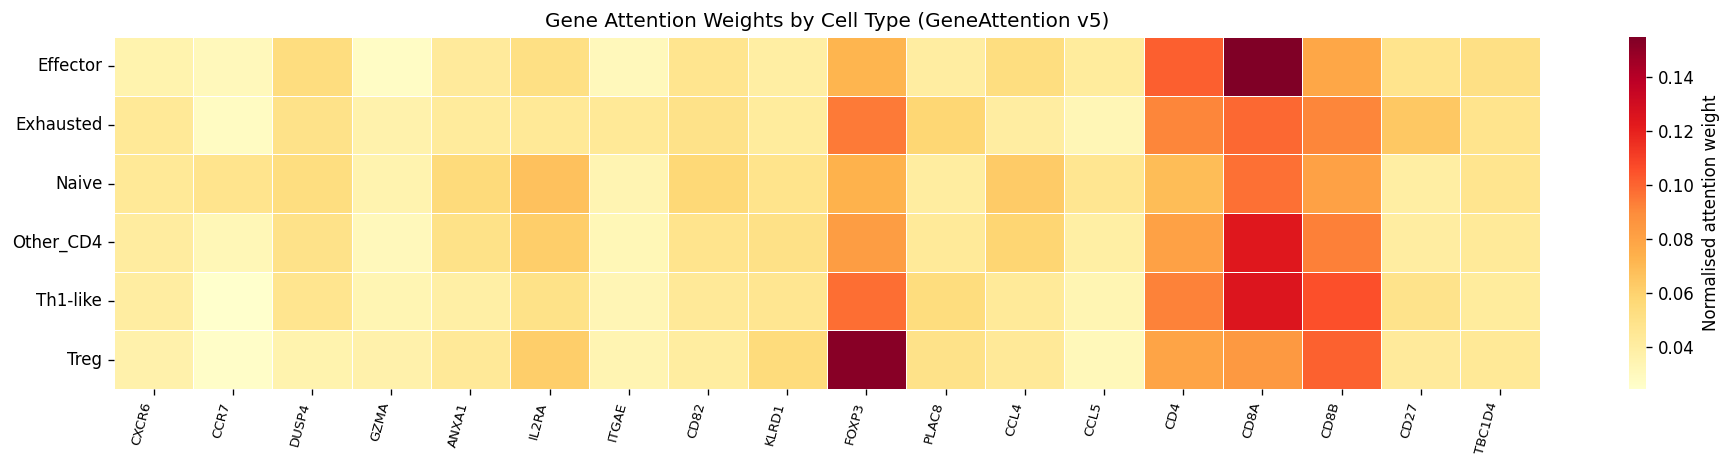

Saved: explainability_output/attention_heatmap.png


In [5]:
# ── Heatmap: top-15 attention genes per class ────────────────────────────────
TOP_HEAT = 15

# Union of top-15 from each class
union_idx = set()
for cls in class_names:
    union_idx.update(np.argsort(class_attention[cls])[::-1][:TOP_HEAT])
union_idx = sorted(union_idx)

heat_data = np.array([class_attention[cls][union_idx] for cls in class_names])
# Normalise each class row to sum=1 for comparability
heat_data = heat_data / heat_data.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(16, len(union_idx)*0.45), 4))
sns.heatmap(
    heat_data,
    xticklabels=gene_names[union_idx],
    yticklabels=class_names,
    cmap="YlOrRd", ax=ax, linewidths=0.3,
    cbar_kws={"label": "Normalised attention weight"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha="right", fontsize=8)
ax.set_title("Gene Attention Weights by Cell Type (GeneAttention v5)", fontsize=12)
plt.tight_layout()
plt.savefig(EXPDIR / "attention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {EXPDIR}/attention_heatmap.png")

## 3 · Integrated Gradients

In [6]:
def integrated_gradients(model, x, target_class, n_steps=50, baseline=None):
    """
    Compute IG attributions for a batch of inputs toward target_class.
    baseline: zero expression (black baseline = silenced gene profile)
    Returns: attributions (same shape as x)
    """
    if baseline is None:
        baseline = tf.zeros_like(x)

    # Interpolate from baseline to input
    alphas    = tf.linspace(0.0, 1.0, n_steps + 1)   # (n_steps+1,)
    gradients = []

    for alpha in alphas:
        interpolated = baseline + alpha * (x - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            preds = model(interpolated, training=False)          # (B, n_classes)
            target_score = preds[:, target_class]
        grad = tape.gradient(target_score, interpolated)         # (B, n_genes)
        gradients.append(grad)

    # Trapezoidal approximation of the integral
    gradients  = tf.stack(gradients, axis=0)                     # (n_steps+1, B, n_genes)
    avg_grads  = (gradients[:-1] + gradients[1:]) / 2.0
    avg_grads  = tf.reduce_mean(avg_grads, axis=0)               # (B, n_genes)
    return ((x - baseline) * avg_grads).numpy()                  # (B, n_genes)


print("Integrated Gradients function defined.")

Integrated Gradients function defined.


In [7]:
N_IG_CELLS  = 150   # cells per class
N_IG_STEPS  = 50
TOP_IG      = 20

ig_per_class = {}   # class_name → mean |IG| (n_genes,)

for c, cls in enumerate(class_names):
    idx = np.where(y_train == c)[0]
    idx = idx[np.random.choice(len(idx), min(N_IG_CELLS, len(idx)), replace=False)]
    x_batch = tf.constant(X_train[idx])

    attr = integrated_gradients(model, x_batch, target_class=c, n_steps=N_IG_STEPS)
    ig_per_class[cls] = np.abs(attr).mean(axis=0)   # mean absolute IG
    print(f"  {cls}: IG computed ({len(idx)} cells)")

print("\nDone.")

  Effector: IG computed (150 cells)


  Exhausted: IG computed (150 cells)


  Naive: IG computed (150 cells)


  Other_CD4: IG computed (150 cells)


  Th1-like: IG computed (150 cells)


  Treg: IG computed (150 cells)

Done.


In [8]:
# ── Top IG genes per class + marker validation ────────────────────────────────
print(f"{'Class':12s}  Top-{TOP_IG} IG genes")
print("-"*80)
ig_top_genes = {}
for cls in class_names:
    top_idx   = np.argsort(ig_per_class[cls])[::-1][:TOP_IG]
    top_genes = gene_names[top_idx].tolist()
    ig_top_genes[cls] = top_genes

    known = KNOWN_MARKERS.get(cls, [])
    hits  = [g for g in top_genes if g in known]
    print(f"{cls:12s}: {', '.join(top_genes[:10])}")
    print(f"{'':12s}  ✓ Known markers: {hits if hits else 'none in top-20'}")
    print()

Class         Top-20 IG genes
--------------------------------------------------------------------------------
Effector    : CD8A, CD4, CD8B, KLRD1, AOAH, CD82, ANXA1, GPR18, TNFRSF25, ITGB1
              ✓ Known markers: ['CD8A', 'CD8B']

Exhausted   : CD8A, CD4, CD8B, ITGAE, CTSW, TC2N, CD27, CCL3, IL7R, FASLG
              ✓ Known markers: none in top-20

Naive       : CCR7, TXK, LEF1, CD8B, AHNAK, PYHIN1, IL10RA, RORA, APOBEC3C, PTGER2
              ✓ Known markers: ['CCR7', 'LEF1', 'SELL']

Other_CD4   : CD8A, CD8B, ANXA1, TXK, CD4, KLRB1, CD40LG, CCR7, CTSB, PTGER2
              ✓ Known markers: ['CD4']

Th1-like    : CD8A, CD8B, CD4, DUSP4, PDCD1, ANXA1, CXCR6, GZMA, PRDM1, FOS
              ✓ Known markers: none in top-20

Treg        : FOXP3, IL2RA, ANXA1, NAMPT, CCL5, ID2, SELL, ALOX5AP, CD82, TBC1D4
              ✓ Known markers: ['FOXP3', 'IL2RA']



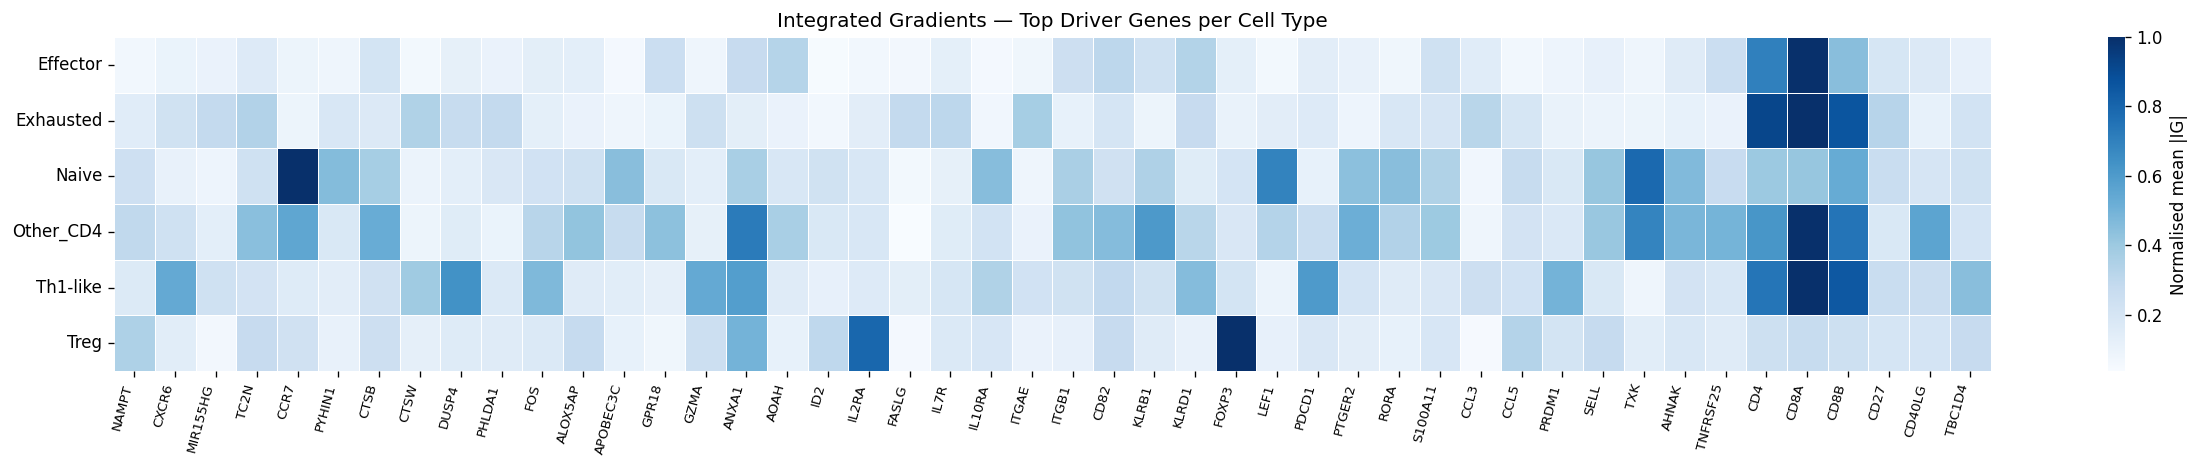

Saved: explainability_output/ig_heatmap.png


In [9]:
# ── IG heatmap ───────────────────────────────────────────────────────────────
TOP_IG_HEAT = 12

union_ig = set()
for cls in class_names:
    union_ig.update(np.argsort(ig_per_class[cls])[::-1][:TOP_IG_HEAT])
union_ig = sorted(union_ig)

ig_data = np.array([ig_per_class[cls][union_ig] for cls in class_names])
# Row-normalise
ig_data = ig_data / (ig_data.max(axis=1, keepdims=True) + 1e-12)

fig, ax = plt.subplots(figsize=(max(14, len(union_ig)*0.45), 4))
sns.heatmap(
    ig_data,
    xticklabels=gene_names[union_ig],
    yticklabels=class_names,
    cmap="Blues", ax=ax, linewidths=0.3,
    cbar_kws={"label": "Normalised mean |IG|"},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha="right", fontsize=8)
ax.set_title("Integrated Gradients — Top Driver Genes per Cell Type", fontsize=12)
plt.tight_layout()
plt.savefig(EXPDIR / "ig_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {EXPDIR}/ig_heatmap.png")

## 4 · Attention vs IG agreement

In [10]:
# Rank correlation between attention weight and IG per class
from scipy.stats import spearmanr

print(f"{'Class':12s}  Spearman ρ (attention vs IG)")
print("-"*45)
for cls in class_names:
    rho, p = spearmanr(class_attention[cls], ig_per_class[cls])
    print(f"{cls:12s}:  ρ = {rho:.3f}  (p={p:.2e})")

Class         Spearman ρ (attention vs IG)
---------------------------------------------
Effector    :  ρ = 0.387  (p=4.76e-97)
Exhausted   :  ρ = 0.373  (p=6.34e-90)
Naive       :  ρ = 0.383  (p=4.84e-95)
Other_CD4   :  ρ = 0.383  (p=2.48e-95)
Th1-like    :  ρ = 0.419  (p=3.63e-115)
Treg        :  ρ = 0.448  (p=8.40e-134)


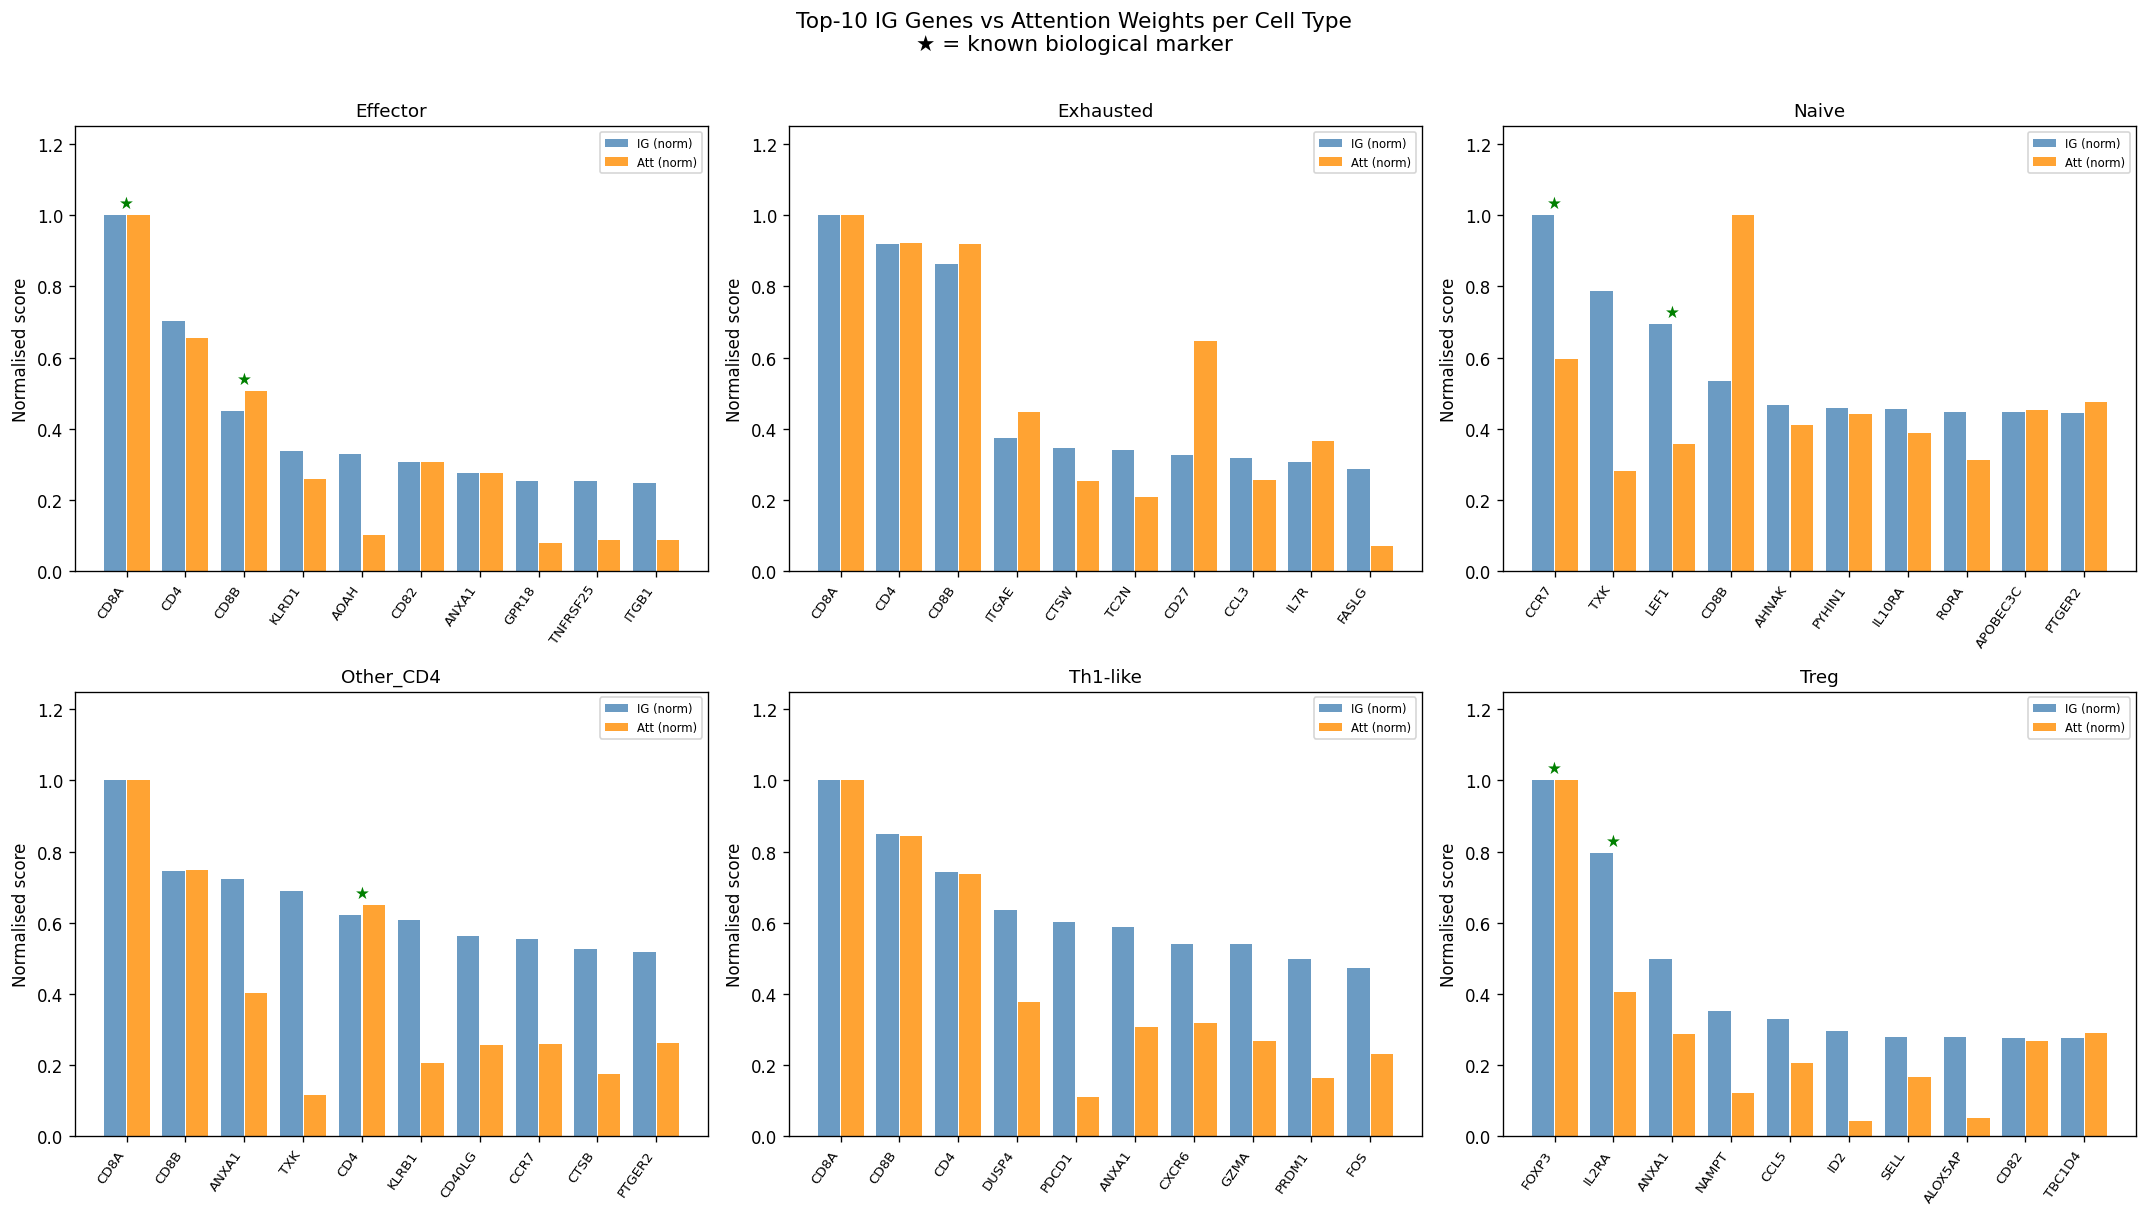

Saved: explainability_output/ig_vs_attention_per_class.png


In [11]:
# ── Side-by-side bar: top-10 IG genes coloured by attention rank ─────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, cls in zip(axes.flat, class_names):
    top_idx   = np.argsort(ig_per_class[cls])[::-1][:10]
    ig_vals   = ig_per_class[cls][top_idx]
    att_vals  = class_attention[cls][top_idx]
    labels    = gene_names[top_idx]

    x = np.arange(len(top_idx))
    ax.bar(x - 0.2, ig_vals  / ig_vals.max(),  0.38, label="IG (norm)",  color="steelblue",  alpha=0.8)
    ax.bar(x + 0.2, att_vals / att_vals.max(), 0.38, label="Att (norm)", color="darkorange", alpha=0.8)

    known = KNOWN_MARKERS.get(cls, [])
    for i, g in enumerate(labels):
        if g in known:
            ax.text(i, max(ig_vals[i]/ig_vals.max(), att_vals[i]/att_vals.max()) + 0.02,
                    "★", ha="center", fontsize=10, color="green")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.set_title(cls, fontsize=11)
    ax.set_ylabel("Normalised score")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.25)

fig.suptitle("Top-10 IG Genes vs Attention Weights per Cell Type\n★ = known biological marker",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(EXPDIR / "ig_vs_attention_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {EXPDIR}/ig_vs_attention_per_class.png")

## 5 · Biological marker recovery summary

In [12]:
print("=" * 65)
print(f"{'Class':12s}  {'IG top-20':^20s}  {'Att top-20':^20s}")
print(f"{'':12s}  {'recovered / total':^20s}  {'recovered / total':^20s}")
print("=" * 65)

for cls in class_names:
    known   = KNOWN_MARKERS.get(cls, [])
    ig_hits  = [g for g in ig_top_genes[cls]  if g in known]
    att_hits = [g for g in top_genes_per_class[cls] if g in known]
    print(f"{cls:12s}  {len(ig_hits)}/{len(known)} → {ig_hits}")
    print(f"{'':12s}  att: {len(att_hits)}/{len(known)} → {att_hits}")
    print()

# Save gene rankings
rankings = {
    cls: {
        "ig_top20":  ig_top_genes[cls],
        "att_top20": top_genes_per_class[cls],
        "ig_marker_hits":  [g for g in ig_top_genes[cls]  if g in KNOWN_MARKERS.get(cls,[])],
        "att_marker_hits": [g for g in top_genes_per_class[cls] if g in KNOWN_MARKERS.get(cls,[])],
    }
    for cls in class_names
}
import json as _json
with open(EXPDIR / "gene_rankings.json", "w") as f:
    _json.dump(rankings, f, indent=2)
print(f"Gene rankings saved to {EXPDIR}/gene_rankings.json")

Class              IG top-20             Att top-20     
               recovered / total     recovered / total  
Effector      2/7 → ['CD8A', 'CD8B']
              att: 2/7 → ['CD8A', 'CD8B']

Exhausted     0/7 → []
              att: 0/7 → []

Naive         3/6 → ['CCR7', 'LEF1', 'SELL']
              att: 2/6 → ['CCR7', 'IL7R']

Other_CD4     1/5 → ['CD4']
              att: 2/5 → ['CD4', 'IL2RA']

Th1-like      0/5 → []
              att: 0/5 → []

Treg          2/5 → ['FOXP3', 'IL2RA']
              att: 2/5 → ['FOXP3', 'IL2RA']

Gene rankings saved to explainability_output/gene_rankings.json
